# QFT vs AQFT: Comparison Analysis


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, state_fidelity, DensityMatrix
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from helpers import make_circuit
from my_qft import qft, aqft

## Experiment 1: Gate count and depth

In [10]:
def get_circuit_stats(n: int, precision: int):
    qc = make_circuit(n, 0)
    aqft(qc, precision)
    qc_decomposed = qc.decompose()
    return qc_decomposed.size(), qc_decomposed.depth()

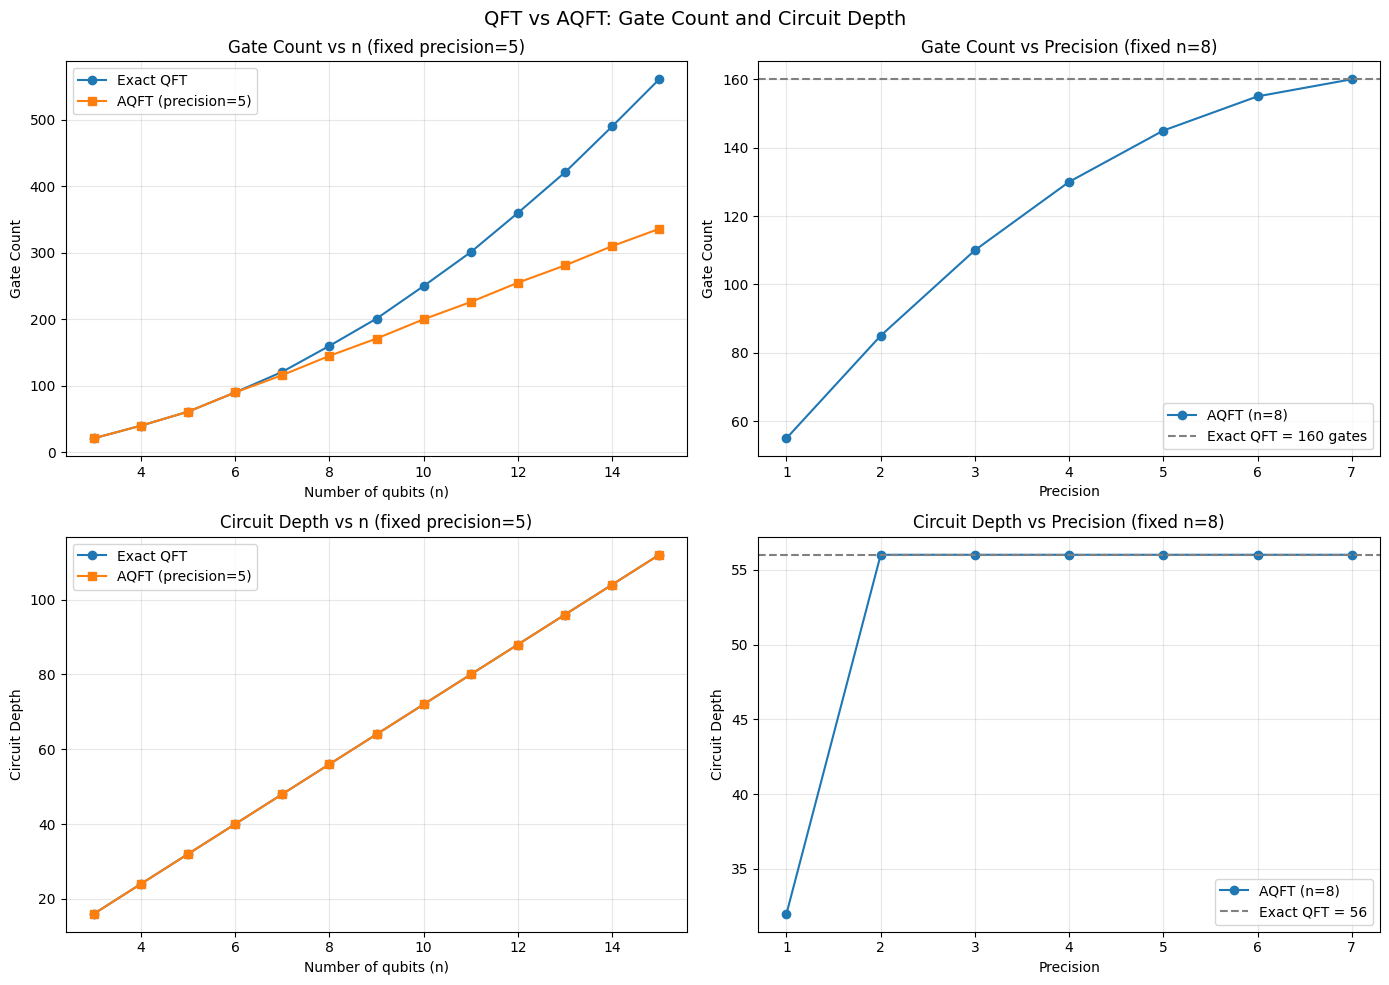

In [30]:
n_values = list(range(3, 16))
fixed_precision = 5

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('QFT vs AQFT: Gate Count and Circuit Depth', fontsize=14)

ax = axes[0, 0]
exact_counts = [get_circuit_stats(n, n-1)[0] for n in n_values]
aqft_counts  = [get_circuit_stats(n, fixed_precision)[0] for n in n_values]
ax.plot(n_values, exact_counts, marker='o', label='Exact QFT')
ax.plot(n_values, aqft_counts,  marker='s', label=f'AQFT (precision={fixed_precision})')
ax.set_xlabel('Number of qubits (n)')
ax.set_ylabel('Gate Count')
ax.set_title(f'Gate Count vs n (fixed precision={fixed_precision})')
ax.legend()
ax.grid(True, alpha=0.3)

fixed_n = 8
precisions = list(range(1, fixed_n))
ax = axes[0, 1]
counts = [get_circuit_stats(fixed_n, p)[0] for p in precisions]
exact_count = get_circuit_stats(fixed_n, fixed_n-1)[0]
ax.plot(precisions, counts, marker='o', label=f'AQFT (n={fixed_n})')
ax.axhline(exact_count, linestyle='--', color='gray', label=f'Exact QFT = {exact_count} gates')
ax.set_xlabel('Precision')
ax.set_ylabel('Gate Count')
ax.set_title(f'Gate Count vs Precision (fixed n={fixed_n})')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
exact_depths = [get_circuit_stats(n, n-1)[1] for n in n_values]
aqft_depths  = [get_circuit_stats(n, fixed_precision)[1] for n in n_values]
ax.plot(n_values, exact_depths, marker='o', label='Exact QFT')
ax.plot(n_values, aqft_depths,  marker='s', label=f'AQFT (precision={fixed_precision})')
ax.set_xlabel('Number of qubits (n)')
ax.set_ylabel('Circuit Depth')
ax.set_title(f'Circuit Depth vs n (fixed precision={fixed_precision})')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
depths = [get_circuit_stats(fixed_n, p)[1] for p in precisions]
exact_depth = get_circuit_stats(fixed_n, fixed_n-1)[1]
ax.plot(precisions, depths, marker='o', label=f'AQFT (n={fixed_n})')
ax.axhline(exact_depth, linestyle='--', color='gray', label=f'Exact QFT = {exact_depth}')
ax.set_xlabel('Precision')
ax.set_ylabel('Circuit Depth')
ax.set_title(f'Circuit Depth vs Precision (fixed n={fixed_n})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Experiment 2: Fidelity vs precision (noiseless)

In [6]:
rng = np.random.default_rng(seed=42)

def worst_case_input(n: int) -> int:
    top_bits = (n + 1) // 2
    return ((1 << top_bits) - 1) << (n - top_bits)


def get_fidelity_noiseless(n: int, initial_number: int, precision: int) -> float:
    qc_exact = make_circuit(n, initial_number)
    qft(qc_exact)

    qc_approx = make_circuit(n, initial_number)
    aqft(qc_approx, precision)

    sv_exact = Statevector(qc_exact)
    sv_approx = Statevector(qc_approx)
    return state_fidelity(sv_exact, sv_approx)


def get_fidelity_stats(n: int, precision: int):
    f_worst = get_fidelity_noiseless(n, worst_case_input(n), precision)

    sample = rng.choice(2**n, size=min(2**n, 64), replace=False)
    fidelities = [get_fidelity_noiseless(n, j, precision) for j in sample]

    return np.mean(fidelities), f_worst

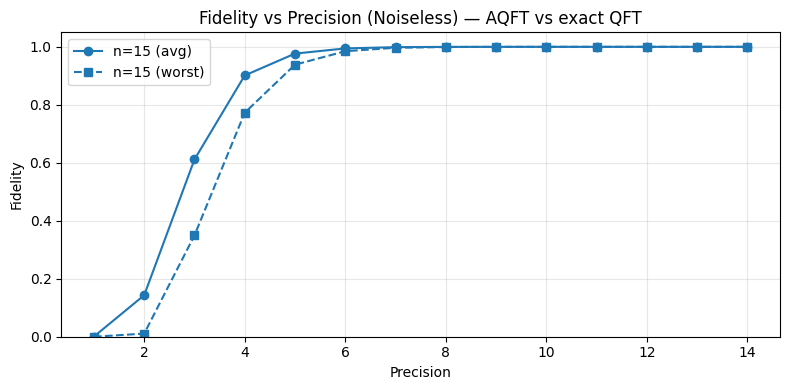

In [32]:
n_values = [15]

fig, ax = plt.subplots(figsize=(8, 4))

for n in n_values:
    precisions = list(range(1, n))
    avg_fidelities, worst_fidelities = zip(*[get_fidelity_stats(n, p) for p in precisions])

    line, = ax.plot(precisions, avg_fidelities, marker='o', label=f'n={n} (avg)')
    ax.plot(precisions, worst_fidelities, color=line.get_color(), marker='s', linestyle='--', label=f'n={n} (worst)')

ax.set_xlabel('Precision')
ax.set_ylabel('Fidelity')
ax.set_title('Fidelity vs Precision (Noiseless) — AQFT vs exact QFT')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Experiment 3: Fidelity vs precision — noisy


In [ ]:
def make_noise_model(single_qubit_error: float, two_qubit_error: float) -> NoiseModel:
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(single_qubit_error, 1), ['h', 'p', 'u', 'sx']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(two_qubit_error, 2), ['cp', 'cx', 'swap']
    )
    return noise_model

def get_fidelity_noisy(
    n: int, initial_number: int, precision: int, sim: AerSimulator
) -> float:
    qc_exact = make_circuit(n, initial_number)
    qft(qc_exact)
    sv_exact = Statevector(qc_exact)

    qc_approx = make_circuit(n, initial_number)
    aqft(qc_approx, precision)
    qc_approx.save_density_matrix()

    job = sim.run(transpile(qc_approx, sim))
    dm_approx = DensityMatrix(job.result().data()['density_matrix'])
    return state_fidelity(sv_exact, dm_approx)


def get_noisy_fidelity_stats(n: int, precision: int, sim: AerSimulator):
    sample = rng.choice(2**n, size=min(2**n, 64), replace=False)
    all_inputs = [worst_case_input(n)] + [int(j) for j in sample]

    circuits = []
    for j in all_inputs:
        qc = make_circuit(n, j)
        aqft(qc, precision)
        qc.save_density_matrix()
        circuits.append(transpile(qc, sim))

    job = sim.run(circuits)
    results = job.result()

    fidelities = []
    for i, j in enumerate(all_inputs):
        qc_exact = make_circuit(n, j)
        qft(qc_exact)
        sv_exact = Statevector(qc_exact)
        dm = DensityMatrix(results.data(i)['density_matrix'])
        fidelities.append(state_fidelity(sv_exact, dm))

    return np.mean(fidelities[1:]), fidelities[0]


def precompute_exact_statevectors(n: int, inputs: list) -> dict:
    cache = {}
    for j in inputs:
        qc = make_circuit(n, j)
        qft(qc)
        cache[j] = Statevector(qc)
    return cache


def precompute_circuits(n: int, precisions: list, inputs: list, sim: AerSimulator) -> dict:
    cache = {}
    for p in precisions:
        circuits = []
        for j in inputs:
            qc = make_circuit(n, j)
            aqft(qc, p)
            qc.save_density_matrix()
            circuits.append(transpile(qc, sim))
        cache[p] = circuits
    return cache

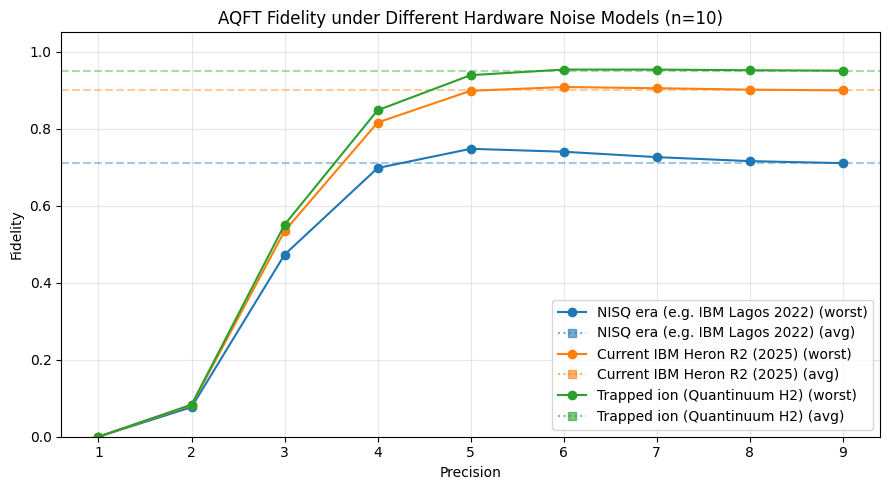

In [12]:
SAMPLE_SIZE = 1
n = 10
precisions = list(range(1, n))

# rng = np.random.default_rng(seed=42)
# sample = [int(j) for j in rng.choice(2**n, size=min(2**n, SAMPLE_SIZE), replace=False)]
# all_inputs = [worst_case_input(n)] + sample

all_inputs = [worst_case_input(n)]


sv_cache = precompute_exact_statevectors(n, all_inputs)

base_sim = AerSimulator(method='density_matrix')
circuit_cache = precompute_circuits(n, precisions, all_inputs, base_sim)

noise_profiles = {
    'NISQ era (e.g. IBM Lagos 2022)':  (1e-3, 1e-2),
    'Current IBM Heron R2 (2025)':     (1e-3, 3e-3),
    'Trapped ion (Quantinuum H2)':     (3e-5, 1.5e-3),
}

fig, ax = plt.subplots(figsize=(9, 5))

for label, (sq_err, tq_err) in noise_profiles.items():
    nm = make_noise_model(sq_err, tq_err)
    sim = AerSimulator(method='density_matrix', noise_model=nm)

    avg_fids, worst_fids = [], []
    for p in precisions:
        job = sim.run(circuit_cache[p])
        results = job.result()

        fidelities = []
        for i, j in enumerate(all_inputs):
            dm = DensityMatrix(results.data(i)['density_matrix'])
            fidelities.append(state_fidelity(sv_cache[j], dm))

        worst_fids.append(fidelities[0])
        avg_fids.append(np.mean(fidelities[1:]))

    exact_job = sim.run(circuit_cache[n - 1])
    exact_results = exact_job.result()
    exact_noisy_worst = state_fidelity(
        sv_cache[worst_case_input(n)],
        DensityMatrix(exact_results.data(0)['density_matrix'])
    )

    line, = ax.plot(precisions, worst_fids, marker='o', label=f'{label} (worst)')
    ax.plot(precisions, avg_fids, color=line.get_color(), marker='s',
            linestyle=':', alpha=0.6, label=f'{label} (avg)')
    ax.axhline(exact_noisy_worst, linestyle='--', color=line.get_color(), alpha=0.4)

ax.set_xlabel('Precision')
ax.set_ylabel('Fidelity')
ax.set_title(f'AQFT Fidelity under Different Hardware Noise Models (n={n})')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()